In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [25]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # Standard parameters
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # Convert scores → gates in (0,1)
        gates = torch.sigmoid(self.gate_scores)

        # Apply pruning
        pruned_weights = self.weight * gates

        # Linear operation
        return x @ pruned_weights.t() + self.bias

In [26]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [27]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

In [28]:
def compute_sparsity_loss(model):
    sparsity_loss = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            sparsity_loss += gates.sum()   # L1 norm

    return sparsity_loss

In [29]:
def train(model, trainloader, epochs, lambda_val):
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            classification_loss = criterion(outputs, labels)
            sparsity_loss = compute_sparsity_loss(model)

            total_loss_batch = classification_loss + lambda_val * sparsity_loss

            total_loss_batch.backward()
            optimizer.step()

            total_loss += total_loss_batch.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

In [30]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [31]:
def compute_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

In [32]:
def plot_gates(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    plt.hist(all_gates, bins=50)
    plt.title("Distribution of Gate Values")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()


Training with lambda = 1e-06
Epoch 1, Loss: 984.82
Epoch 2, Loss: 868.87
Epoch 3, Loss: 807.78
Epoch 4, Loss: 759.71
Epoch 5, Loss: 718.14
Epoch 6, Loss: 681.63
Epoch 7, Loss: 646.02
Epoch 8, Loss: 613.24
Epoch 9, Loss: 581.27
Epoch 10, Loss: 552.53
Accuracy: 55.97%
Sparsity: 0.01%


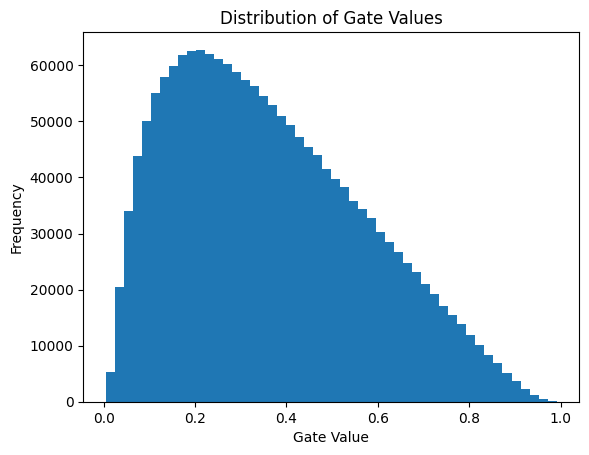


Training with lambda = 1e-05
Epoch 1, Loss: 3753.89
Epoch 2, Loss: 3201.40
Epoch 3, Loss: 2771.25
Epoch 4, Loss: 2426.30
Epoch 5, Loss: 2152.51
Epoch 6, Loss: 1935.45
Epoch 7, Loss: 1763.00
Epoch 8, Loss: 1623.32
Epoch 9, Loss: 1507.45
Epoch 10, Loss: 1410.13
Accuracy: 55.71%
Sparsity: 0.43%


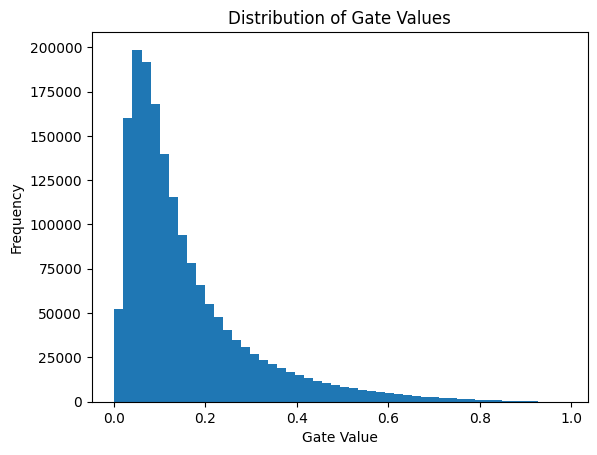


Training with lambda = 0.0001
Epoch 1, Loss: 31365.12
Epoch 2, Loss: 26080.13
Epoch 3, Loss: 21278.16
Epoch 4, Loss: 17128.68
Epoch 5, Loss: 13722.17
Epoch 6, Loss: 11034.65
Epoch 7, Loss: 8963.69
Epoch 8, Loss: 7379.23
Epoch 9, Loss: 6163.65
Epoch 10, Loss: 5220.62
Accuracy: 56.16%
Sparsity: 1.45%


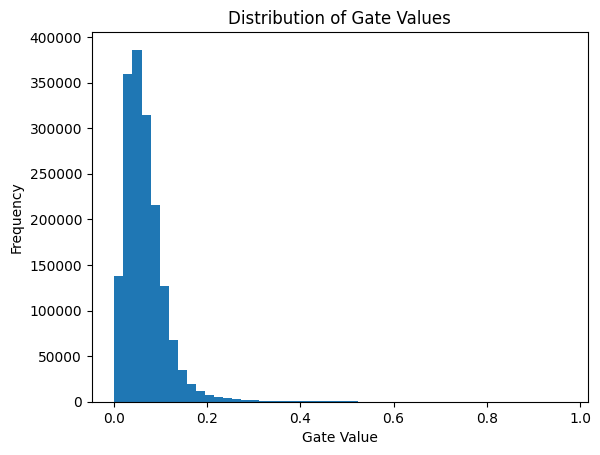

In [33]:
lambdas = [1e-6, 1e-5, 1e-4]

results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = PrunableNet()

    train(model, trainloader, epochs=10, lambda_val=lam)

    acc = evaluate(model)
    sparsity = compute_sparsity(model)

    print(f"Accuracy: {acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")

    results.append((lam, acc, sparsity))

    plot_gates(model)